# River Park Flows

Streamflow and discharge data for the North Branch of the Chicago River (NBCR) 
and the North Shore Channel (NSC) upstream of River Park, Chicago, IL.

Data sources:
- **USGS NWIS** — gauge discharge data retrieved via the 
  [dataretrieval](https://doi-usgs.github.io/dataretrieval-python/) package
- **MWRD** — O'Brien Water Reclamation Plant outfall data from 
  [mwrd.org](https://mwrd.org/search)

Figures generated by this notebook appear in the ENVI-101 Water Quality I lab handout.

*Unit conversions: 1 acre-foot = 43,560 ft³ · 1 acre-foot/day = 0.505 cfs · 1 cfs = 0.6463 MGD*

## License
Copyright (C) 2025 Greg Anderson

This notebook is free software: 
you can redistribute them and/or modify them under the terms of the 
[GNU General Public License v3](LICENSE) as published by the Free Software Foundation.

Data from USGS NWIS services is in the public domain.


In [12]:
import datetime as dt
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
from dataretrieval import nwis

## MWRD Data

Outfall data from the O'Brien plant from the MWRD spreadsheet "O'Brien Outfall 2021-2030.xlsx" which can be found at https://mwrd.org/search

Text(0, 0.5, 'Flow (MGD)')

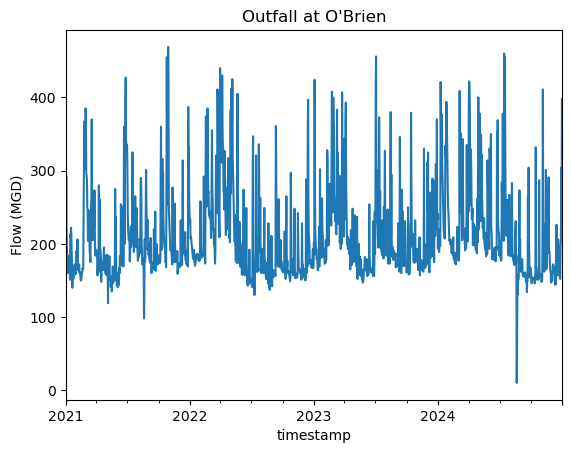

In [2]:
dv_obrien = pd.read_csv("data/obrien_outfall_timeseries.csv", 
                        parse_dates=["timestamp"])
ax = dv_obrien.set_index("timestamp").plot(y="FLOW", legend=False, title="Outfall at O'Brien")  # swap FLOW for any column
ax.set_ylabel("Flow (MGD)")

## NWIS Data Access via *dataretrieval*

The `dataretrieval` package provides Python access to USGS NWIS data. The primary
function used here is `nwis.get_record()`, which returns a pandas DataFrame for a
given **service** type:

| Service | Description |
|---|---|
| `dv` | Daily values |
| `iv` | Instantaneous values |
| `site` | Site metadata |
| `gwlevels` | Groundwater levels |
| `pmcodes` | Parameter codes |

**Key arguments:**
- `sites` — USGS site identifier string or list of strings
- `start`, `end` — date range as `"YYYY-MM-DD"` strings
- `parameterCd` — USGS parameter code (e.g. `"00060"` for discharge)
- `statCd` — statistic code: `00001` max, `00002` min, `00003` mean

You can browse the sites and information used here at
  - https://waterdata.usgs.gov/nwis/inventory or 
  - https://maps.waterdata.usgs.gov/mapper/index.html

For full documentation see the
[dataretrieval user guide](https://doi-usgs.github.io/dataretrieval-python/userguide/index.html)
and the [USGS parameter code list](https://help.waterdata.usgs.gov/codes-and-parameters/parameters).

## Configuration

In [3]:
# USGS Parameter Codes

Water_Temperature_C = "00010"
Air_Temperature_C = "00020"
Mean_Discharge_CFS   = "00060"   # Mean
Discharge_CFS   = "00061"   # Instantaneous
Gauge_Height_FT = "00065"   # Instantaneous

CFS_TO_MGD = 0.6463169      # 1 cfs = 0.6463169 MGD
MGD_TO_CFS = 1.0 / CFS_TO_MGD  # = 1.5472287 cfs per MGD


In [4]:
# Selected USGS Gauges

Skokie_R_LF =  '05535000'   # Skokie River at Lake Forest
Skokie_R_HP = '05535070'    # Skokie River at Highland Park
WF_NBCR = '05535500'        # WF NBCR at Nortbrook IL
NBCR_Deerfield = '05534500' # MF NBCR at Deefield, IL
NBCR_Niles = '05536000'     # NBCR at Niles, IL
NBCR_Pulaski = '05536085'   # NBCR at Pulaski Rd
NBCR_GrandAve = '05536118'  # NBCR at Grand Ave (discharge data ended in 2010)

In [5]:
# Start and end date strings are of the form YYYY-MM-DD:

start_date = '2020-01-01' # string start date
end_date =  '2024-12-31' #  string end date

In [6]:
# North Branch of the Chicago River at Pulaski (Daily Values)

dv_2020 = nwis.get_record(sites=NBCR_Pulaski, service='dv', start='2020-01-01', end='2020-12-31')
dv_2021 = nwis.get_record(sites=NBCR_Pulaski, service='dv', start='2021-01-01', end='2021-12-31')
dv_2022 = nwis.get_record(sites=NBCR_Pulaski, service='dv', start='2022-01-01', end='2022-12-31') 
dv_2023 = nwis.get_record(sites=NBCR_Pulaski, service='dv', start='2023-01-01', end='2023-12-31') 
dv_2024 = nwis.get_record(sites=NBCR_Pulaski, service='dv', start='2024-01-01', end='2024-12-31') 
dv_2025 = nwis.get_record(sites=NBCR_Pulaski, service='dv', start='2025-01-01', end='2025-12-31') 

dv = nwis.get_record(sites=NBCR_Pulaski, service='dv', start=start_date, end=end_date)

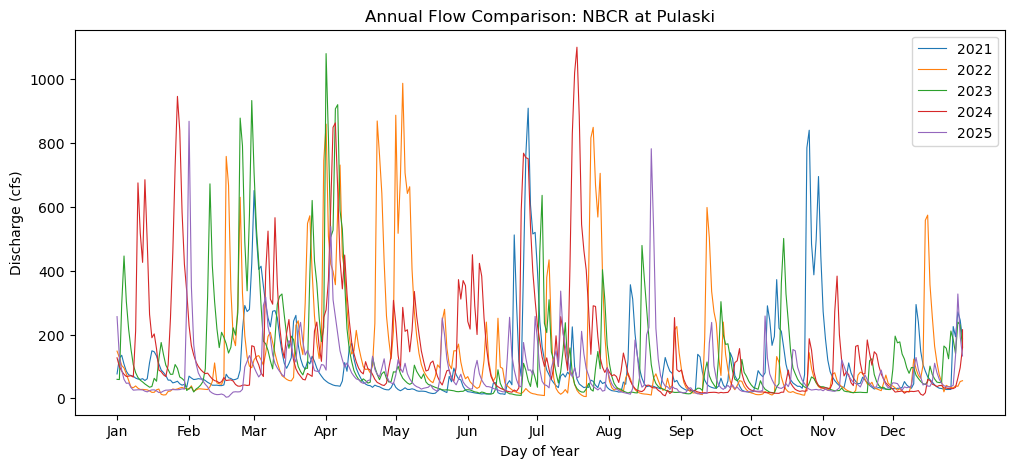

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

for year, dv_year in [(2021, dv_2021), (2022, dv_2022), (2023, dv_2023), (2024, dv_2024), (2025, dv_2025)]:
    df = dv_year.copy()
    df["doy"] = df.index.day_of_year
    # For leap years, clip day 366 to 365
    df["doy"] = df["doy"].clip(upper=365)
    ax.plot(df["doy"], df["00060_Mean"], linewidth=0.8, label=str(year))

ax.set_xlabel("Day of Year")
ax.set_ylabel("Discharge (cfs)")
ax.set_title("Annual Flow Comparison: NBCR at Pulaski")
ax.legend()

# Optional: replace day-of-year numbers with month labels
ax.set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335])
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.show()

### Exploratory Plot: Daily Mean Flow at Pulaski

Text(0.5, 1.0, 'Daily Mean Flow: North Branch of the Chicago River')

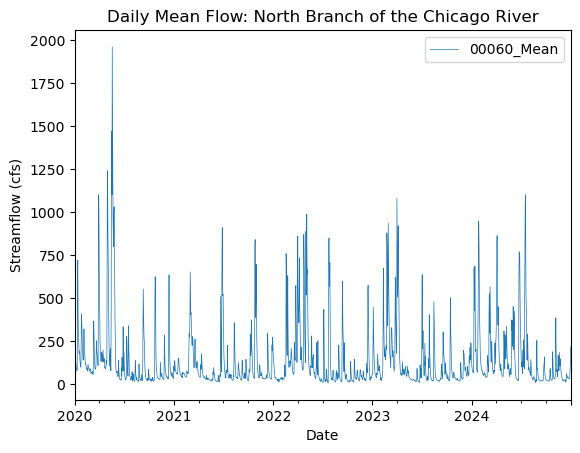

In [8]:
ax = dv.plot(y='00060_Mean',linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Streamflow (cfs)')
ax.set_title('Daily Mean Flow: North Branch of the Chicago River')

## USGS NBCR gauges closest to River Park

In [9]:
# Instantaneous values
iv_pulaski = nwis.get_record(sites=NBCR_Pulaski, service='iv', start=start_date, end=end_date)
iv_niles =  nwis.get_record(sites=NBCR_Niles, service='iv', start=start_date, end=end_date) 
iv_deerfield  = nwis.get_record(sites=NBCR_Deerfield, service='iv', start=start_date, end=end_date) 

In [10]:
# get basic info about the site

md_pulaski = nwis.get_record(sites=NBCR_Pulaski, service='site')
md_niles = nwis.get_record(sites=NBCR_Niles, service='site')
md_deerfield = nwis.get_record(sites=NBCR_Deerfield, service='site')
Agency_Name = md_pulaski.loc[0]['agency_cd']

## River Park Flow Comparison

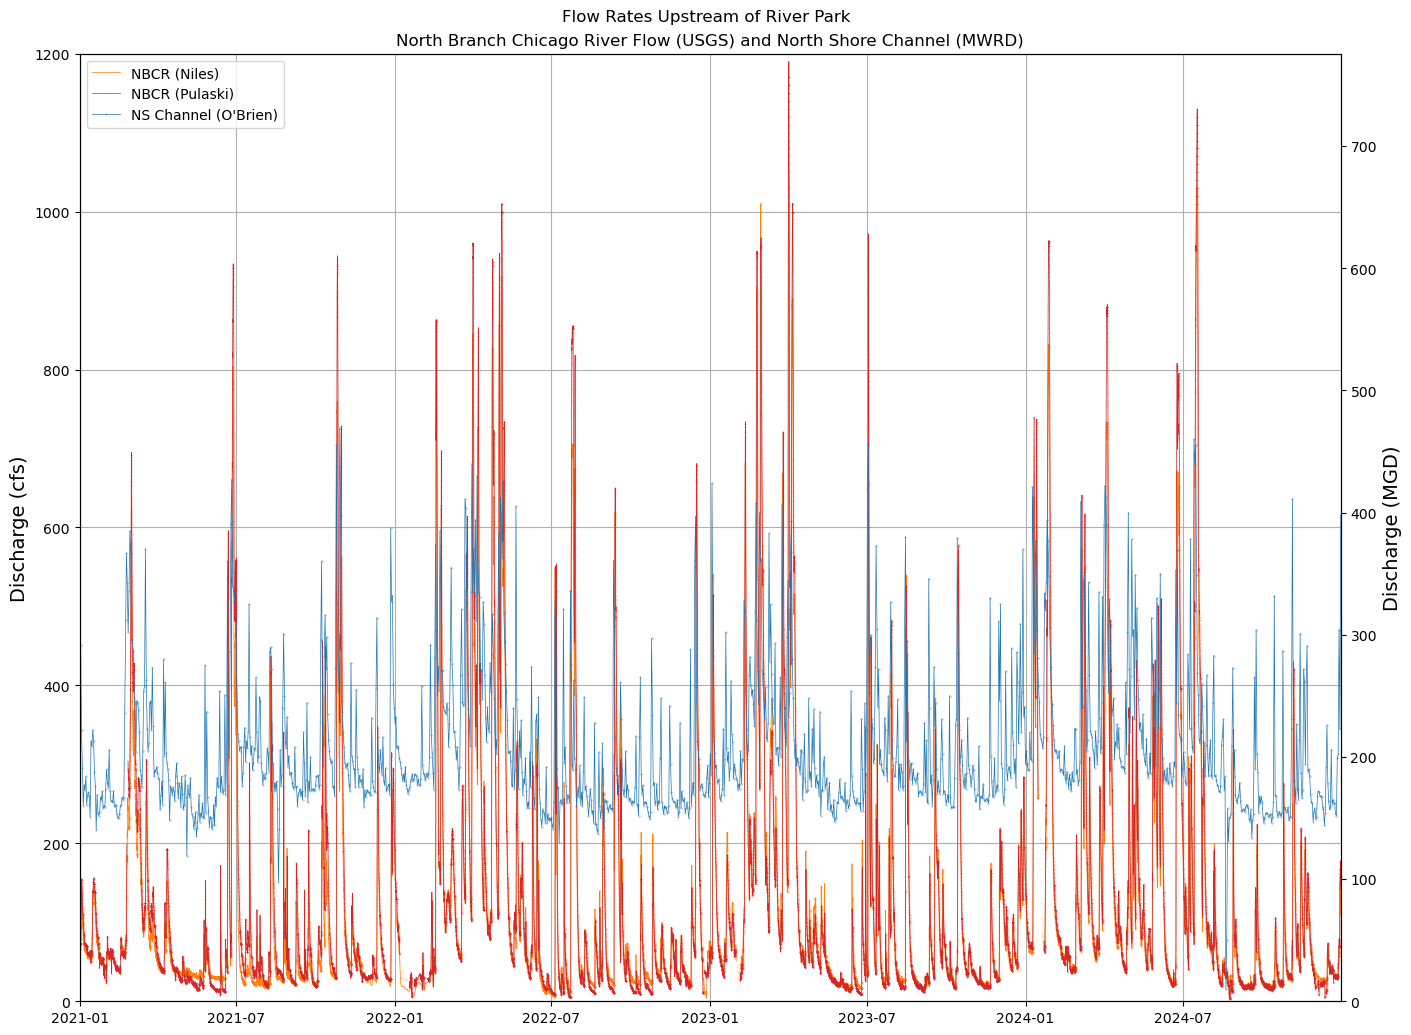

In [13]:
# Plot starts 2021 (earliest year with O'Brien MWRD outfall data)
start_dt = dt.datetime(2021,1,1,tzinfo=dt.timezone.utc)
end_dt = dt.datetime(2024,12,31,tzinfo=dt.timezone.utc)

fig, ax1 = plt.subplots(1, 1, figsize=(14, 10), constrained_layout=True)
fig.suptitle('Flow Rates Upstream of River Park',y=1.02, fontsize=12)

ax1.grid(True)

# Instantaneous Values

ax1.axis([start_dt,end_dt,0,1200]) #iv_pulaski['00060'].max()])
ax1.set_ylabel('Discharge (cfs)', fontsize=14)
ax1.set_title("North Branch Chicago River Flow (" + Agency_Name + ") and North Shore Channel (MWRD)")

ax1r = ax1.twinx()
ax1r.set_ylabel('Discharge (MGD)', fontsize=14)

ymin_cfs, ymax_cfs = ax1.get_ylim()
ax1r.set_ylim(ymin_cfs * CFS_TO_MGD, ymax_cfs * CFS_TO_MGD)

ax1.plot(iv_niles.index, iv_niles['00060'], 
         color='tab:orange',
         linestyle='solid',
         marker='o',
         markersize=0.02,
         label = 'NBCR (Niles)',
         linewidth=0.5)

ax1.plot(iv_pulaski.index, iv_pulaski['00060'], 
         color='tab:red',
         linestyle='solid',
         marker='s',
         markersize=0.02,
         label='NBCR (Pulaski)',
         linewidth=0.5)


ax1.plot(dv_obrien["timestamp"], 
         dv_obrien["FLOW"]* MGD_TO_CFS, # convert MGD to CFS 
         color='tab:blue',
         linestyle='-',
         marker='.',
         markersize=0.5,
         label = 'NS Channel (O\'Brien)',
         linewidth=0.5)

ax1.legend()

output_dir = Path("./figures")
output_dir.mkdir(exist_ok=True)

plt.savefig('./figures/river_park_flow.png')
plt.show()